In [1]:
import pandas as pd
from tqdm import tqdm
import os
import datetime as dt
import sys
import glob

In [2]:
sys.path.append("/data/workspace/libs/pytools")
db_dir = "/data/workspace/Data/DataBase"
from mfrt.research_tools import DBTool

In [3]:
from mfrt.opt_backtest import OptBacktest
from mfrt.eval_netvalue import EvalNetValue
opt_bt=OptBacktest(db_dir)
eval_NV=EvalNetValue(db_dir)

from mfrt.eval_factor import EvalFactor
eval_F = EvalFactor(db_dir)

check_Barra_list=('BETA', 'MOMENTUM', 'SIZE', 'RESVOL', 'BTOP', 'LIQUIDTY',  'SPRET', 'SIZENL', 'GROWTH', 'LEVERAGE')
def test_factor(factor: pd.DataFrame, 
                start_dt, 
                end_dt, 
                display: bool=True, 
                if_trade_tmr: bool=True, 
                specific_return: bool=False,
                Universe=None,
                return_type='Vwap') -> dict:
    F_res=eval_F.quick_test(factor,start_dt=start_dt,end_dt=end_dt,Group_Num=10,Horizon=10,Return_Type=return_type,
                        Specific_Return=specific_return,Universe=Universe,check_Barra_list=check_Barra_list,
                        extraExp_check_dict=None,if_trade_tmr=if_trade_tmr, display=display)
    
    return F_res

In [4]:
df = pd.read_parquet("/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/gubapost_cls/trained_subspace_heads/trained_fc_prob_L_oos.parquet")
# result = df[
#     (df["method"] == "decay_20d_hl10") & 
#     (df["layer"] == 11) &
#     (df["source_split"] == "test")
# ][["trading_date", "symbol", "factor_value"]]

In [5]:
# df["sum"] = df["sentiment_mean"] * df["n_posts"]
df

symbol,000001,000002,000004,000006,000007,000008,000009,000010,000011,000012,...,688788,688789,688793,688795,688798,688799,688800,688819,688981,689009
date,,,,,,,,,,,,,,,,,,,,,
2024-06-03,7.316531,6.977129,7.825823,6.970644,0.514284,8.054401,7.308164,6.715569,4.145612,6.935292,...,7.319695,1.920932,2.026025,NaN,3.876689,4.601913,6.899062,4.103360,8.304730,7.517336
2024-06-04,2.070128,1.892838,1.852685,1.728225,1.838218,1.619095,1.878768,1.814129,1.917790,1.891614,...,1.761700,1.943293,1.850829,NaN,0.384205,0.524630,0.578840,1.701573,1.988934,1.881687
2024-06-05,2.136193,1.819868,1.767580,1.888011,0.536999,1.857858,1.492963,1.918026,1.829289,1.699075,...,1.936549,0.537754,0.463371,NaN,1.669208,0.510211,1.790386,1.898757,1.765201,1.754415
2024-06-06,1.822593,1.771878,1.891034,1.731117,1.720191,1.979950,1.993438,1.844275,1.781976,1.722241,...,0.447775,0.503167,0.577967,NaN,0.417056,1.693205,0.482347,1.920303,1.543102,1.597194
2024-06-07,1.899448,1.938708,1.779741,2.012864,1.842451,1.849312,1.859821,1.618914,0.423256,1.841706,...,1.719731,0.567046,0.414240,NaN,1.853767,1.882521,0.460732,1.929072,1.952974,2.099857
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-31,1.455041,1.759714,1.595744,1.772566,1.702661,1.825870,1.696346,1.883814,1.885194,1.706707,...,1.496146,1.924463,1.698965,1.710118,0.506124,1.713579,1.806713,0.445738,1.778561,1.780503
2026-01-05,10.794810,15.259389,10.721614,16.455502,1.969900,15.182998,15.883117,6.999322,10.171950,17.788958,...,18.319799,4.318834,15.979699,16.727177,10.799641,3.940976,4.268320,10.906708,17.332636,10.873234
2026-01-06,1.788753,1.713795,1.664265,2.017147,1.660425,2.300696,1.791130,1.777496,2.064311,1.867594,...,1.806970,1.829159,1.693057,1.945475,1.780586,1.972301,1.921789,0.486475,1.777830,1.787829


In [6]:
# factor_wide = df.set_index(['available_date', 'symbol'])['sum'].unstack()
# factor_wide.index.name = 'date' 

In [7]:
# # 只保留沪深A股：0/3开头(深) + 6开头(沪)，去掉4/8开头(北交所/新三板)
# factor_wide = factor_wide[[c for c in factor_wide.columns if str(c)[0] in '036']]

In [8]:
# factor_wide

In [9]:
import pandas as pd

# 自动添加后缀：6开头加.SH，其他加.SZ
def add_suffix(col_code):
    if str(col_code).startswith('6'):
        return col_code + '.SH'
    else:
        return col_code + '.SZ'

# # factor_wide.index.name = 'date' # 确保行索引有名字
# # factor_wide.columns = [add_suffix(c) for c in factor_wide.columns]

df.index.name = 'date' # 确保行索引有名字
df.columns = [add_suffix(c) for c in df.columns]
print(df.head()) # 检查一下表头是否变成了 000032.SZ
# # print(factor_wide.head()) # 检查一下表头是否变成了 000032.SZ

            000001.SZ  000002.SZ  000004.SZ  000006.SZ  000007.SZ  000008.SZ  \
date                                                                           
2024-06-03   7.316531   6.977129   7.825823   6.970644   0.514284   8.054401   
2024-06-04   2.070128   1.892838   1.852685   1.728225   1.838218   1.619095   
2024-06-05   2.136193   1.819868   1.767580   1.888011   0.536999   1.857858   
2024-06-06   1.822593   1.771878   1.891034   1.731117   1.720191   1.979950   
2024-06-07   1.899448   1.938708   1.779741   2.012864   1.842451   1.849312   

            000009.SZ  000010.SZ  000011.SZ  000012.SZ  ...  688788.SH  \
date                                                    ...              
2024-06-03   7.308164   6.715569   4.145612   6.935292  ...   7.319695   
2024-06-04   1.878768   1.814129   1.917790   1.891614  ...   1.761700   
2024-06-05   1.492963   1.918026   1.829289   1.699075  ...   1.936549   
2024-06-06   1.993438   1.844275   1.781976   1.722241  ...   0.44777

In [10]:
# pd.read_parquet("/home/intern_fjq_2026/Projects/chinese-wwm-roberta/artifacts/gubapost_baseline/probs_daily/gubapost_probs_20200101.parquet")

In [11]:
# pd.read_parquet("/home/intern_fjq_2026/data/NLP/gubapost/2020/gubapost20200101.parquet")

In [12]:
# 转换为时间戳并升序排列 + 清除 NaT 日期
# factor_wide.index = pd.to_datetime(factor_wide.index, errors='coerce')
# factor_wide = factor_wide[factor_wide.index.notna()]  # 删掉 'None' 等无效日期行
# factor_wide = factor_wide.sort_index()

# print(f"日期范围：{factor_wide.index.min().date()} 到 {factor_wide.index.max().date()}")
# print(f"列数：{len(factor_wide.columns)}")

df.index = pd.to_datetime(df.index, errors='coerce')
df = df[df.index.notna()]  # 删掉 'None' 等无效日期行
df = df.sort_index()

print(f"日期范围：{df.index.min().date()} 到 {df.index.max().date()}")
print(f"列数：{len(df.columns)}")

日期范围：2024-06-03 到 2026-01-08
列数：5240


,IC,ICIR,Coverage,AutoCorr,LS_AnnRtn,LS_Sharpe,LS_AnnRtn_RbyH,LS_Sharpe_RbyH
0,0.41%,0.169,98.6%,24.1%,0.1%,0.04,0.4%,0.21


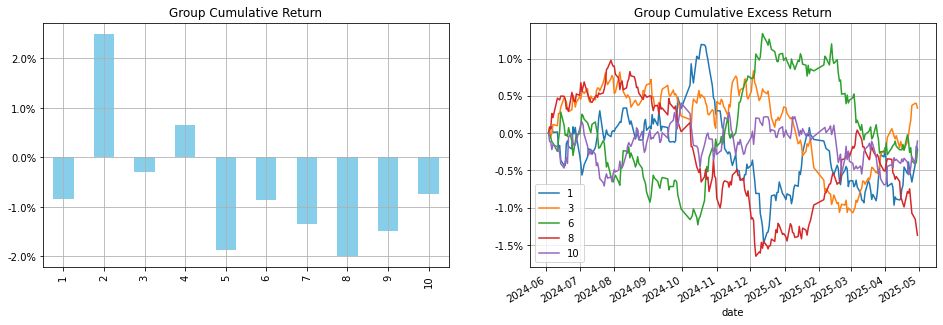

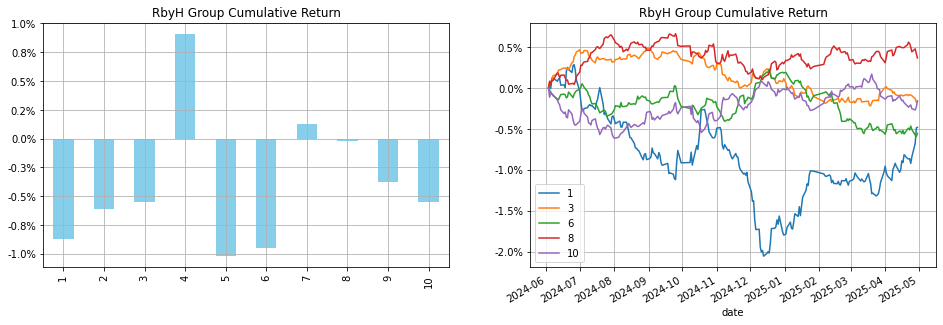

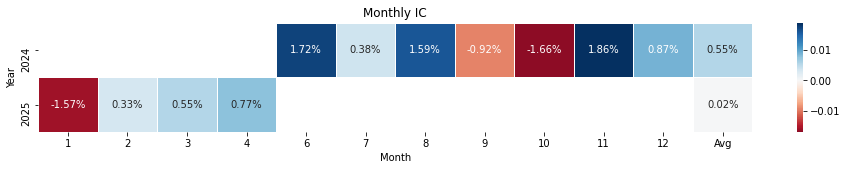

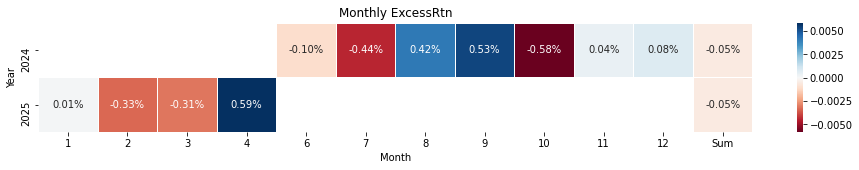

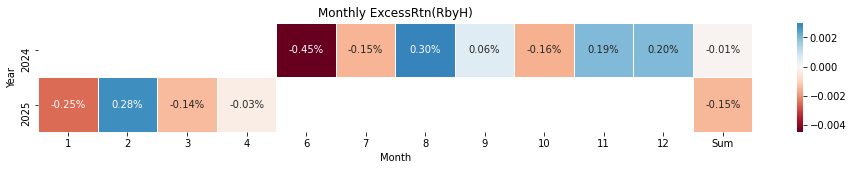

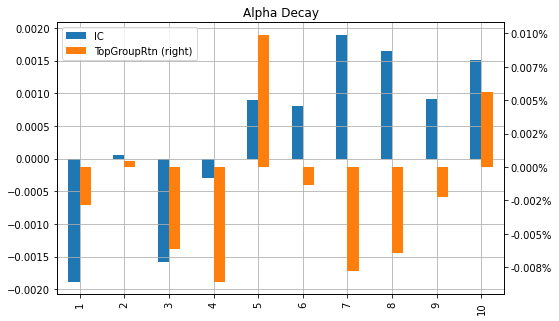

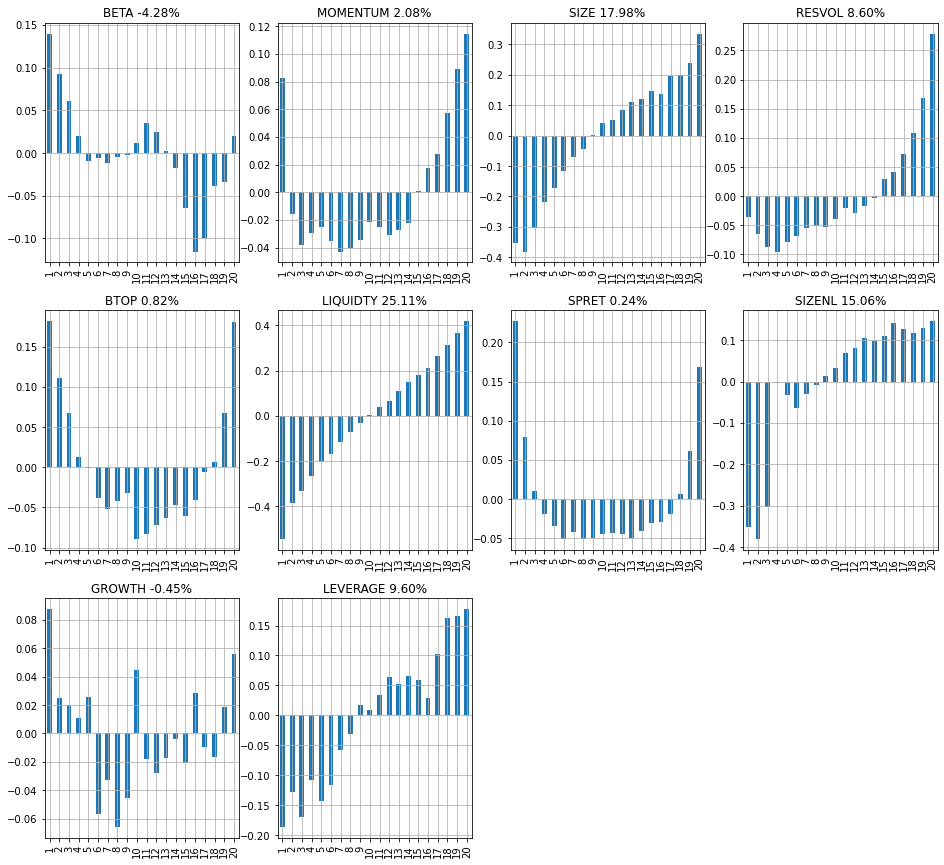

In [14]:
res = test_factor(
            df.dropna(how="all", axis=0),
            start_dt='2024-06-03', 
            end_dt='2025.05.01', 
            if_trade_tmr=True,
            specific_return=True,
            return_type="Vwap",
        )
res